# PadChest-GR — evaluation



## 1. Setup

In [ ]:
!pip install -q transformers accelerate bitsandbytes peft datasets
!pip install -q nltk rouge-score
print("done — restart if Colab asks, then re-run from here")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
done — restart if Colab asks, then re-run from here


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, time, math, random, hashlib, shutil, subprocess
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUT_ROOT = "/content/drive/MyDrive/MSC_VLM_GROUNDED"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("runs:", sorted(d for d in os.listdir(OUT_ROOT) if d.startswith("run_")))

Mounted at /content/drive
device: cuda
runs: ['run_A_iu', 'run_A_iu_unified', 'run_B_COLLAPSED_mlp_adapter', 'run_B_final', 'run_B_final_ep1_IoU069', 'run_B_final_ep23', 'run_B_final_ep3', 'run_B_final_ep4', 'run_B_gf0.5_COLLAPSED_lr1e-4_accum16', 'run_B_linearMLP', 'run_B_linearMLP_s1', 'run_B_lora5e6', 'run_B_padchest_gf0.5']


### 1.1 Restore data

In [ ]:
PNG_TAR, PNG_LOCAL = f"{OUT_ROOT}/pcgr_png.tar", "/content/pc_png"
if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
    if not os.path.isdir(PNG_LOCAL) or len(os.listdir(PNG_LOCAL)) < 100:
        subprocess.run(["tar", "-xf", PNG_TAR, "-C", "/content"])
    if not os.path.exists(f"{PNG_LOCAL}/manifest.json"):
        shutil.copy(f"{OUT_ROOT}/manifest.json", f"{PNG_LOCAL}/manifest.json")

pc_all = json.load(open(f"{PNG_LOCAL}/manifest.json"))
print(f"{len(pc_all)} studies")
assert len(pc_all) == 4555

4555 studies


## 2. Definitions

Config, prompts, coordinate vocabulary, geometry, target formatting, abstention rules.

In [ ]:
import re

class CFG:
    SEED = 42

    # vision
    IMG_SIZE = 518
    PATCH = 14
    RAW_GRID = 37                  # 518 / 14
    POOL_GRID = 19                 # 361 tokens — fits a T4; keeps raster order
    VISION_DIM = 768

    # coordinate vocabulary
    COORD_BINS = 32                # -> 64 tokens (32 x + 32 y)

    # llm
    LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
    LORA_R = 32
    LORA_ALPHA = 64
    LORA_DROPOUT = 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]


    EPOCHS = 1                     # checkpoints every 300 steps
    BATCH = 1
    ACCUM = 8                     # effective batch 16
    LR = 2e-6
    LR_ADAPTER = 5e-5
    WARMUP_FRAC = 0.03
    MAX_LEN = 512
    GROUNDED_FRACTION = 1.0        # abnormal-only run: every sample grounded

    # decoding
    MAX_NEW_TOKENS = 220
    DO_SAMPLE = True               # greedy under-produces boxes
    TOP_P = 0.9
    TEMPERATURE = 0.7


def seed_everything(s=CFG.SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


# ==============================================================================
# PROMPTS
# ==============================================================================

SYSTEM = ("<|im_start|>system\nYou are an expert radiology assistant tasked "
          "with interpreting a chest X-ray study.<|im_end|>\n")

INSTR_FINDGEN = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence.<|im_end|>\n<|im_start|>assistant\n")

INSTR_GROUNDREP = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence. If the finding is groundable, locate it in the image with "
    "bounding boxes indicating all locations where it can be seen. Otherwise "
    "generate just the ungrounded finding.<|im_end|>\n<|im_start|>assistant\n")


# ==============================================================================
# COORDINATE VOCABULARY
# ==============================================================================

OBJ_OPEN, OBJ_CLOSE = "<obj>", "</obj>"
BOX_OPEN, BOX_CLOSE = "<box>", "</box>"


def coord_tokens(n=CFG.COORD_BINS):
    return ([f"<x{i}>" for i in range(n)] + [f"<y{i}>" for i in range(n)]
            + [OBJ_OPEN, OBJ_CLOSE, BOX_OPEN, BOX_CLOSE])


def add_coord_tokens(tokenizer, model, n=CFG.COORD_BINS):
    """
    Add coordinate tokens with PER-TOKEN random initialisation.

    NOT the global mean. Qwen2.5 ties input and output embeddings, so a row set
    to the average of all rows has near-zero distinctive dot product with any
    hidden state and the softmax ranks it BELOW uniform. Measured on this setup:
    new tokens started at NLL 20-27 against ln(151665)=11.93 for uniform, i.e.
    worse than random. Every added token was maximally improbable, and the
    cheapest way for the optimiser to reduce loss was to stop emitting
    structured output entirely.

    Initialising from the empirical mean plus per-dimension noise puts new
    tokens near uniform (~11.9) instead: uninformative but learnable.
    """
    new = coord_tokens(n)
    added = tokenizer.add_tokens(new, special_tokens=True)
    if added == 0:
        return tokenizer, model
    model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        emb = model.get_input_embeddings().weight
        old = emb[:-added].float()
        mu, sd = old.mean(0, keepdim=True), old.std(0, keepdim=True)
        emb[-added:] = (mu + torch.randn(added, emb.shape[1],
                                         device=emb.device) * sd).to(emb.dtype)
        out = model.get_output_embeddings()
        if out is not None and out.weight.data_ptr() != emb.data_ptr():
            o = out.weight[:-added].float()
            om, os_ = o.mean(0, keepdim=True), o.std(0, keepdim=True)
            out.weight[-added:] = (om + torch.randn(added, o.shape[1],
                                                    device=o.device) * os_
                                   ).to(out.weight.dtype)
        chk = emb[-added:]
        spread = chk.float().std(0).mean().item()
    print(f"added {added} tokens | vocab {len(tokenizer)} | "
          f"new-row spread {spread:.5f} (must be > 0)")
    assert spread > 1e-4, "coordinate tokens are identical — init failed"
    return tokenizer, model


def box_to_tokens(box_norm, n=CFG.COORD_BINS):
    """(x0,y0,x1,y1) normalised to [0,1] -> '<x><y><x><y>' token string."""
    x0, y0, x1, y1 = box_norm
    q = lambda v: int(np.clip(round(v * (n - 1)), 0, n - 1))
    return f"<x{q(x0)}><y{q(y0)}><x{q(x1)}><y{q(y1)}>"


BOX_RE = re.compile(r"<x(\d+)><y(\d+)><x(\d+)><y(\d+)>")


def parse_generation(text, n=CFG.COORD_BINS):
    """
    Decode model output -> [(sentence, [boxes_norm])].
    A sentence with no <box> is an ABSTENTION, which is a valid output.
    """
    out = []
    for chunk in re.findall(r"<obj>(.*?)</obj>", text, flags=re.S):
        boxes = [(int(a)/(n-1), int(b)/(n-1), int(c)/(n-1), int(d)/(n-1))
                 for a, b, c, d in BOX_RE.findall(chunk)]
        sent = re.sub(r"<box>.*?</box>", "", chunk, flags=re.S)
        sent = BOX_RE.sub("", sent).strip()
        if sent:
            out.append((sent, boxes))
    if not out and text.strip():                  # ungrounded fallback
        out = [(text.strip(), [])]
    return out


# ==============================================================================
# GEOMETRY — image and boxes through the identical transform
# ==============================================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], np.float32)


def preprocess(pil_img, boxes_xyxy=None, size=CFG.IMG_SIZE):
    """
    Resize shortest side to `size`, centre-crop `size` — matches Rad-DINO and
    MAIRA-2. Boxes go through the SAME transform and come back normalised to
    [0,1] in cropped space. Boxes losing >70% of their area are dropped and
    reported, so the loss rate is visible rather than silent.
    """
    W, H = pil_img.size
    scale = size / min(W, H)
    nw, nh = int(round(W * scale)), int(round(H * scale))
    img = pil_img.convert("RGB").resize((nw, nh), Image.BILINEAR)
    ox, oy = max(0, (nw - size) // 2), max(0, (nh - size) // 2)
    img = img.crop((ox, oy, ox + size, oy + size))

    arr = np.asarray(img, np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    px = torch.from_numpy(arr).permute(2, 0, 1)

    if boxes_xyxy is None:
        return px, None, img

    out = []
    for b in boxes_xyxy:
        nb = (b[0]*scale - ox, b[1]*scale - oy, b[2]*scale - ox, b[3]*scale - oy)
        cl = (max(0., nb[0]), max(0., nb[1]),
              min(float(size), nb[2]), min(float(size), nb[3]))
        oa = max(1e-6, (nb[2]-nb[0]) * (nb[3]-nb[1]))
        sa = max(0., cl[2]-cl[0]) * max(0., cl[3]-cl[1])
        out.append(tuple(v / size for v in cl) if sa/oa >= 0.30 else None)
    return px, out, img




In [ ]:
# ==============================================================================
# TARGET FORMATTING
# ==============================================================================

def format_findgen(sentences):
    """Run A, and the ungrounded half of Run B."""
    return " ".join(s.strip() for s in sentences if s.strip())


def format_groundrep(sentences, boxes_per_sentence):
    """
    Run B grounded target:
        <obj>There is a right pleural effusion.<box><x12><y20><x25><y28></box></obj>
        <obj>No pneumothorax.</obj>          <- abstention, no box tokens
    """
    parts = []
    for sent, boxes in zip(sentences, boxes_per_sentence):
        s = sent.strip()
        if not s:
            continue
        valid = [b for b in boxes if b is not None]
        if valid:
            btxt = "".join(BOX_OPEN + box_to_tokens(b) + BOX_CLOSE for b in valid)
            parts.append(f"{OBJ_OPEN}{s}{btxt}{OBJ_CLOSE}")
        else:
            parts.append(f"{OBJ_OPEN}{s}{OBJ_CLOSE}")
    return "".join(parts)


# ==============================================================================
# ABSTENTION — three categories
# ==============================================================================

NEGATION_CUES = ["no ", "not ", "without", "free of", "clear of", "negative for",
                 "absence of", "absent", "unremarkable", "normal limits",
                 "within normal", "no evidence"]
NORMALITY_CUES = ["are clear", "is clear", "is normal", "are normal",
                  "unremarkable", "within normal limits", "no abnormalit",
                  "intact", "well-inflated", "well expanded"]
NON_LOCALISABLE_CUES = ["diffuse", "generalised", "generalized", "widespread",
                        "throughout", "global", "hyperinflat", "hypoinflat",
                        "low lung volumes", "emphysema", "copd", "osteopenia",
                        "deminerali", "scoliosis"]


def is_groundable(sentence):
    s = " " + sentence.lower().strip() + " "
    if any(c in s for c in NEGATION_CUES):        return False
    if any(c in s for c in NORMALITY_CUES):       return False
    if any(c in s for c in NON_LOCALISABLE_CUES): return False
    return True


# ==============================================================================
# SPLITS
# ==============================================================================

def study_key(text):
    """
    IU X-ray has no patient ID and is flattened one row per IMAGE. Frontal and
    lateral of one study share the SAME report string, so hashing the
    normalised report recovers study-level grouping. Without this the frontal
    lands in train and the lateral in test with identical target text.
    """
    return hashlib.md5(re.sub(r"\s+", " ", (text or "").strip().lower())
                       .encode()).hexdigest()


def group_split(keys, frac=(0.8, 0.1, 0.1), seed=CFG.SEED):
    uniq = sorted(set(keys)); random.Random(seed).shuffle(uniq)
    n, a, b = len(uniq), int(len(uniq)*frac[0]), int(len(uniq)*(frac[0]+frac[1]))
    assign = {k: ("train" if i < a else "val" if i < b else "test")
              for i, k in enumerate(uniq)}
    out = {"train": [], "val": [], "test": []}
    for i, k in enumerate(keys):
        out[assign[k]].append(i)
    return out


def symmetry_score(pil_img, size=128):
    """Frontal CXRs are near left-right symmetric; laterals are not."""
    a = np.asarray(pil_img.convert("L").resize((size, size)), np.float32)
    b = a[:, ::-1]
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return float((a * b).mean())


FRONTAL_THRESHOLD = 0.68

### 2.1 Adapter

Linear + LayerNorm + learnable scale. A 4-layer MLP collapsed here (signal-to-shared ratio 0.040); this preserves input variance (0.42 at init).

In [ ]:
class SpatialMLPAdapter(nn.Module):


    def __init__(self, vision_dim=CFG.VISION_DIM, llm_dim=2048,
                 raw_grid=CFG.RAW_GRID, pool_grid=CFG.POOL_GRID,
                 target_norm=1.0):
        super().__init__()
        self.raw_grid, self.pool_grid = raw_grid, pool_grid
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.norm = nn.LayerNorm(llm_dim)
        self.scale = nn.Parameter(torch.tensor(target_norm / (llm_dim ** 0.5)))

    def forward(self, rad_out):
        x = rad_out[:, 1:, :]
        B, N, C = x.shape
        assert N == self.raw_grid ** 2, (
            f"expected {self.raw_grid**2} patches, got {N}")
        x = x.transpose(1, 2).reshape(B, C, self.raw_grid, self.raw_grid)
        x = F.adaptive_avg_pool2d(x, (self.pool_grid, self.pool_grid))
        x = x.flatten(2).transpose(1, 2)
        return self.norm(self.proj(x)) * self.scale


seed_everything()
print("adapter class ready")

adapter class ready


### 2.2 Split and dataset

In [ ]:
def patient_level_split(manifest, frac=(0.80, 0.10, 0.10), seed=42):
    groups = {}
    for m in manifest:
        groups.setdefault(str(m["patient_id"]), []).append(m)
    abn = [k for k, v in groups.items() if any(x["abnormal"] for x in v)]
    nrm = [k for k, v in groups.items() if not any(x["abnormal"] for x in v)]
    rng = random.Random(seed); rng.shuffle(abn); rng.shuffle(nrm)
    out = {"train": [], "val": [], "test": []}
    ids = {"train": set(), "val": set(), "test": set()}
    for pool in (abn, nrm):
        a, b = int(len(pool)*frac[0]), int(len(pool)*(frac[0]+frac[1]))
        for nm, ks in [("train", pool[:a]), ("val", pool[a:b]), ("test", pool[b:])]:
            for k in ks:
                out[nm].extend(groups[k]); ids[nm].add(k)
    assert ids["train"].isdisjoint(ids["val"])
    assert ids["train"].isdisjoint(ids["test"])
    assert ids["val"].isdisjoint(ids["test"])
    return out["train"], out["val"], out["test"]


pc_train, pc_val, pc_test = patient_level_split(pc_all)
tr_abn = [m for m in pc_train if m["abnormal"]]
va_abn = [m for m in pc_val   if m["abnormal"]]
te_abn = [m for m in pc_test  if m["abnormal"]]

ns = sum(len(m["sentences"]) for m in tr_abn)
ng = sum(sum(1 for b in m["boxes"] if b) for m in tr_abn)
print(f"ABNORMAL-ONLY  train {len(tr_abn)} | val {len(va_abn)} | test {len(te_abn)}")
print(f"train sentences {ns} | with box {ng} ({100*ng/ns:.1f}%)")
print("\n(full split was 3643/456/456 at 68.0% abnormal)")

pc_train, pc_val, pc_test = patient_level_split(pc_all)
tr_abn = [m for m in pc_train if m["abnormal"]]
va_abn = [m for m in pc_val   if m["abnormal"]]
te_abn = [m for m in pc_test  if m["abnormal"]]
ns = sum(len(m["sentences"]) for m in te_abn)
ng = sum(sum(1 for b in m["boxes"] if b) for m in te_abn)
print(f"TEST abnormal {len(te_abn)} studies | {ns} sentences | "
      f"{ng} boxed ({100*ng/max(1,ns):.1f}%)")

ABNORMAL-ONLY  train 2479 | val 310 | test 310
train sentences 6955 | with box 5034 (72.4%)

(full split was 3643/456/456 at 68.0% abnormal)
TEST abnormal 310 studies | 882 sentences | 620 boxed (70.3%)


In [ ]:
def assign_objective(study_path, grounded_fraction, seed=CFG.SEED):

    h = hashlib.md5(f"{seed}:{study_path}".encode()).hexdigest()
    return "grounded" if (int(h[:8], 16) % 10000) / 10000.0 < grounded_fraction \
        else "findgen"

class PadChestGRDataset(Dataset):

    def __init__(self, studies, gf, seed=CFG.SEED, quiet=False):
        self.studies = studies
        self.obj = [assign_objective(s["path"], gf, seed) for s in studies]
        if not quiet:
            n_g = sum(1 for o in self.obj if o == "grounded")
            print(f"  {n_g} grounded / {len(self.obj)-n_g} ungrounded "
                  f"({100*n_g/max(1,len(self.obj)):.1f}%)")

    def __len__(self): return len(self.studies)

    def __getitem__(self, i):
        s = self.studies[i]
        img = Image.open(s["path"])
        flat = [b for bl in s["boxes"] for b in bl]
        px, tx, _ = preprocess(img, flat)
        reg, k = [], 0
        for bl in s["boxes"]:
            g = []
            for _ in bl:
                if tx[k] is not None: g.append(tx[k])
                k += 1
            reg.append(g)
        if self.obj[i] == "grounded":
            return {"px": px, "target": format_groundrep(s["sentences"], reg),
                    "instr": INSTR_GROUNDREP, "objective": "grounded"}
        return {"px": px, "target": format_findgen(s["sentences"]),
                "instr": INSTR_FINDGEN, "objective": "findgen"}

## 3. Load the trained model



In [ ]:
def build_model():
    from transformers import (AutoModel, AutoTokenizer, AutoModelForCausalLM,
                              BitsAndBytesConfig)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    print("Rad-DINO (frozen)...")
    vision = AutoModel.from_pretrained("microsoft/rad-dino").to(device).eval()
    for p in vision.parameters():
        p.requires_grad = False

    print("Qwen2.5-3B (4-bit) + LoRA...")
    tok = AutoTokenizer.from_pretrained(CFG.LLM_ID)
    tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True,
                             bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=torch.float16)
    base = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_ID, quantization_config=bnb, device_map={"": 0})


    tok, base = add_coord_tokens(tok, base)
    base = prepare_model_for_kbit_training(base)


    lora = LoraConfig(r=CFG.LORA_R, lora_alpha=CFG.LORA_ALPHA,
                      lora_dropout=CFG.LORA_DROPOUT, bias="none",
                      task_type="CAUSAL_LM", target_modules=CFG.LORA_TARGETS)
    llm = get_peft_model(base, lora)
    llm.config.use_cache = False
    llm.gradient_checkpointing_enable()
    llm.enable_input_require_grads()


    n_new = len(coord_tokens())
    emb = llm.get_input_embeddings()
    emb.weight.requires_grad_(True)
    mask = torch.zeros(emb.weight.shape[0], 1,
                       device=emb.weight.device, dtype=emb.weight.dtype)
    mask[-n_new:] = 1.0
    emb.weight.register_hook(lambda g: g * mask)
    llm._n_new_tokens = n_new

    adapter = SpatialMLPAdapter(llm_dim=llm.config.hidden_size).to(device)

    n_ad = sum(p.numel() for p in adapter.parameters())
    n_lora = sum(p.numel() for n, p in llm.named_parameters()
                 if p.requires_grad and "embed_tokens" not in n)
    n_emb_eff = n_new * emb.weight.shape[1]        # effective, after masking
    n_frozen = sum(p.numel() for p in llm.parameters()) \
        + sum(p.numel() for p in vision.parameters())
    tot = n_ad + n_lora + n_emb_eff
    print(f"\nTRAINABLE PARAMETERS")
    print(f"  MLP adapter          {n_ad:>12,}")
    print(f"  LoRA (r={CFG.LORA_R})           {n_lora:>12,}")
    print(f"  coord embeddings     {n_emb_eff:>12,}  "
          f"({n_new} tokens x {emb.weight.shape[1]})")
    print(f"  ------------------------------------")
    print(f"  total trainable      {tot:>12,}  ({100*tot/max(1,n_frozen):.2f}% "
          f"of the frozen backbone)")
    return vision, tok, llm, adapter

In [ ]:
import os, torch, pandas as pd

def list_checkpoints():

    rows = []
    for run in sorted(os.listdir(OUT_ROOT)):
        d = os.path.join(OUT_ROOT, run)
        if not (run.startswith("run_") and os.path.isdir(d)):
            continue

        sl = os.path.join(d, "steplog.json")
        if os.path.exists(sl):
            for r in json.load(open(sl)):
                rows.append({"run": run,
                             "file": (f"ep{r.get('epoch','?')}_"
                                      f"{'final' if r.get('step')=='final' else 'step'+str(r.get('step'))}.pt"),
                             "epoch": r.get("epoch"), "step": r.get("step"),
                             "loss": round(r.get("loss", float("nan")), 4),
                             "n_box": r.get("n_box"), "boxes": r.get("boxes"),
                             "inverted": r.get("inverted"),
                             "p_box": round(r.get("p_box", 0), 3)})
            continue

        for f in sorted(os.listdir(d)):
            if f.endswith(".pt"):
                rows.append({"run": run, "file": f,
                             "size_MB": round(os.path.getsize(os.path.join(d, f))/1e6),
                             "epoch": None, "step": None, "loss": None,
                             "n_box": None, "boxes": None, "inverted": None,
                             "p_box": None})
    return rows

ck = pd.DataFrame(list_checkpoints())
print(ck.to_string(index=False) if len(ck) else "no checkpoints found")

                                 run            file  size_MB  epoch  step   loss  n_box  boxes  inverted  p_box
                    run_A_iu_unified          ep1.pt   1489.0    NaN  None    NaN    NaN    NaN       NaN    NaN
                    run_A_iu_unified          ep2.pt   1489.0    NaN  None    NaN    NaN    NaN       NaN    NaN
                    run_A_iu_unified          ep3.pt   1489.0    NaN  None    NaN    NaN    NaN       NaN    NaN
         run_B_COLLAPSED_mlp_adapter  train_state.pt   4619.0    NaN  None    NaN    NaN    NaN       NaN    NaN
                         run_B_final  ep?_step300.pt      NaN    NaN   300 8.4601    1.0    NaN       NaN  0.000
                         run_B_final  ep?_step600.pt      NaN    NaN   600 7.5778    1.0    NaN       NaN  0.000
                         run_B_final  ep?_step900.pt      NaN    NaN   900 5.7555    0.0    NaN       NaN  0.000
                         run_B_final ep?_step1200.pt      NaN    NaN  1200 4.2629    1.0    NaN 

In [ ]:
import os
RUN = "run_B_final_ep23"
print(sorted(os.listdir(f"{OUT_ROOT}/{RUN}")))

['cam_comparison.json', 'cam_comparison_final.json', 'cam_qualitative.png', 'cam_qualitative_5methods.png', 'ep1_final.pt', 'ep1_step1200.pt', 'ep1_step1500.pt', 'ep1_step1800.pt', 'ep1_step2100.pt', 'ep1_step2400.pt', 'ep1_step300.pt', 'ep1_step600.pt', 'ep1_step900.pt', 'ep2_final.pt', 'ep2_step1200.pt', 'ep2_step1500.pt', 'ep2_step1800.pt', 'ep2_step2100.pt', 'ep2_step2400.pt', 'ep2_step300.pt', 'ep2_step600.pt', 'ep2_step900.pt', 'grounding_eval.json', 'qualitative.png', 'results.json', 'results_corrected.json', 'steplog.json', 'tokenizer']


In [ ]:
import json
print(json.dumps(json.load(open(f"{OUT_ROOT}/{RUN}/steplog.json")), indent=1))

[
 {
  "epoch": 1,
  "step": 300,
  "loss": 2.963105749289195,
  "distinct": 4,
  "n_box": 4,
  "boxes": 0,
  "inverted": 0,
  "inv_pct": 0.0,
  "p_box": 0.22149060666561127,
  "signal": 0.35741972559251894
 },
 {
  "epoch": 1,
  "step": 600,
  "loss": 2.7492127970854443,
  "distinct": 4,
  "n_box": 3,
  "boxes": 0,
  "inverted": 0,
  "inv_pct": 0.0,
  "p_box": 0.4476243555545807,
  "signal": 0.35180500330623826
 },
 {
  "epoch": 1,
  "step": 900,
  "loss": 2.538625177939733,
  "distinct": 4,
  "n_box": 3,
  "boxes": 1,
  "inverted": 1,
  "inv_pct": 100.0,
  "p_box": 0.5387802720069885,
  "signal": 0.3503502319507026
 },
 {
  "epoch": 1,
  "step": 1200,
  "loss": 2.425957702000936,
  "distinct": 4,
  "n_box": 4,
  "boxes": 0,
  "inverted": 0,
  "inv_pct": 0.0,
  "p_box": 0.8546953797340393,
  "signal": 0.35025097714088144
 },
 {
  "epoch": 1,
  "step": 1500,
  "loss": 2.382822101910909,
  "distinct": 4,
  "n_box": 2,
  "boxes": 1,
  "inverted": 0,
  "inv_pct": 0.0,
  "p_box": 0.8185072

### 3.1 Choose and load

In [ ]:
# EDIT: the checkpoint to evaluate — pick the one with the best P(<box>)
RUN  = "run_B_final_ep23"
CKPT = "ep2_final.pt"

from peft import set_peft_model_state_dict
vision, tok, llm, adapter = build_model()

path = f"{OUT_ROOT}/{RUN}/{CKPT}"
st = torch.load(path, map_location=device, weights_only=False)
adapter.load_state_dict(st["adapter"])
set_peft_model_state_dict(llm, st["lora"])
with torch.no_grad():
    w = llm.get_input_embeddings().weight
    w[-68:] = st["coord"].to(w.dtype).to(w.device)
llm.eval(); adapter.eval()
print(f"\nloaded {path}")
print(f"  epoch {st.get('epoch')} step {st.get('step')} | "
      f"loss {st.get('loss')} | P(<box>) {st.get('p_box')}")

Rad-DINO (frozen)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

added 68 tokens | vocab 151733 | new-row spread 0.02339 (must be > 0)

TRAINABLE PARAMETERS
  MLP adapter             1,579,009
  LoRA (r=32)             59,867,136
  coord embeddings          139,264  (68 tokens x 2048)
  ------------------------------------
  total trainable        61,585,409  (3.34% of the frozen backbone)

loaded /content/drive/MyDrive/MSC_VLM_GROUNDED/run_B_final_ep23/ep2_final.pt
  epoch 2 step final | loss 2.0581153617751213 | P(<box>) 0.9604679346084595


## 4. Decoders

`generate_free` is standard sampling. `generate_constrained` forces
`<x><y><x><y>` inside a box — order only, not choice.

# greedy decoder

In [ ]:
# ============================================================
# GREEDY DECODERS
# ============================================================

import torch
import numpy as np
from PIL import Image


# ------------------------------------------------------------
# Coordinate-token IDs
# ------------------------------------------------------------

X_IDS = torch.tensor(
    tok.convert_tokens_to_ids([f"<x{i}>" for i in range(32)])
)

Y_IDS = torch.tensor(
    tok.convert_tokens_to_ids([f"<y{i}>" for i in range(32)])
)

BOX_O = tok.convert_tokens_to_ids("<box>")
BOX_C = tok.convert_tokens_to_ids("</box>")
OBJ_O = tok.convert_tokens_to_ids("<obj>")
OBJ_C = tok.convert_tokens_to_ids("</obj>")


# ============================================================
# 1. GREEDY CONSTRAINED DECODER
# ============================================================

@torch.no_grad()
def generate_constrained_greedy(
    study,
    max_new=200,
    max_obj=4
):
    """
    Greedy constrained generation.

    Outside <box>:
        - standard greedy decoding using argmax

    Inside <box>:
        - force coordinate structure:
          <x><y><x><y></box>

    No temperature or top-p sampling is used.

    The model still chooses the actual coordinate tokens;
    only the coordinate grammar is constrained.
    """

    # --------------------------------------------------------
    # Image encoding
    # --------------------------------------------------------

    px, _, _ = preprocess(
        Image.open(study["path"])
    )

    vis = adapter(
        encode_image(
            vision,
            px[None]
        ).float()
    )

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    ids = tok(
        SYSTEM + INSTR_GROUNDREP + "<obj>",
        return_tensors="pt"
    )["input_ids"].to(device)

    emb = llm.get_input_embeddings()(ids)

    inp = torch.cat(
        [vis.to(emb.dtype), emb],
        dim=1
    )

    # --------------------------------------------------------
    # Generation state
    # --------------------------------------------------------

    out_ids = []

    # -1 = outside box
    #  0 = expecting x1
    #  1 = expecting y1
    #  2 = expecting x2
    #  3 = expecting y2
    in_box = -1

    n_obj = 1

    # --------------------------------------------------------
    # Autoregressive generation
    # --------------------------------------------------------

    for _ in range(max_new):

        with torch.amp.autocast(
            "cuda",
            dtype=torch.float16
        ):

            logits = llm(
                inputs_embeds=inp,
                attention_mask=torch.ones(
                    inp.shape[:2],
                    dtype=torch.long,
                    device=device
                )
            ).logits[0, -1].float()

        # ====================================================
        # INSIDE <box>
        # ====================================================

        if in_box >= 0:

            # Even positions -> x coordinates
            # Odd positions  -> y coordinates
            allowed = (
                X_IDS
                if in_box % 2 == 0
                else Y_IDS
            ).to(device)

            constrained_logits = torch.full_like(
                logits,
                float("-inf")
            )

            constrained_logits[allowed] = logits[allowed]

            logits = constrained_logits

        # ====================================================
        # OUTSIDE <box>
        # ====================================================

        else:

            # </box> is illegal outside a box
            logits[BOX_C] = float("-inf")

            # Coordinates are illegal outside a box
            logits[X_IDS.to(device)] = float("-inf")
            logits[Y_IDS.to(device)] = float("-inf")

            # Discourage repeated <obj>
            if out_ids and out_ids[-1] == OBJ_C:
                logits[OBJ_O] -= 3.0

        # ====================================================
        # GREEDY SELECTION
        # ====================================================

        nxt = torch.argmax(logits).item()

        # ====================================================
        # HANDLE COORDINATES
        # ====================================================

        if in_box >= 0:

            out_ids.append(nxt)

            in_box += 1

            # After x1,y1,x2,y2 automatically close box
            if in_box == 4:

                out_ids.append(BOX_C)

                in_box = -1

        # ====================================================
        # START BOX
        # ====================================================

        elif nxt == BOX_O:

            out_ids.append(nxt)

            in_box = 0

        # ====================================================
        # END OBJECT
        # ====================================================

        elif nxt == OBJ_C:

            out_ids.append(nxt)

            n_obj += 1

            # Keep your current one-finding evaluation
            break

        # ====================================================
        # NORMAL TEXT TOKEN
        # ====================================================

        else:

            out_ids.append(nxt)

        # ----------------------------------------------------
        # Stop conditions
        # ----------------------------------------------------

        if nxt == tok.eos_token_id:
            break

        if n_obj > max_obj:
            break

        # ----------------------------------------------------
        # Append selected token embedding
        # ----------------------------------------------------

        e = llm.get_input_embeddings()(
            torch.tensor(
                [[nxt]],
                device=device
            )
        )

        inp = torch.cat(
            [inp, e.to(inp.dtype)],
            dim=1
        )

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    txt = tok.decode(
        out_ids,
        skip_special_tokens=False
    )

    txt = txt.split("<|im_end|>")[0]

    return "<obj>" + txt


# ============================================================
# 2. FREE GREEDY DECODER
# ============================================================

@torch.no_grad()
def generate_free_greedy(
    study,
    max_new=200
):


    # --------------------------------------------------------
    # Image encoding
    # --------------------------------------------------------

    px, _, _ = preprocess(
        Image.open(study["path"])
    )

    vis = adapter(
        encode_image(
            vision,
            px[None]
        ).float()
    )

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    ids = tok(
        SYSTEM + INSTR_GROUNDREP + "<obj>",
        return_tensors="pt"
    )["input_ids"].to(device)

    emb = llm.get_input_embeddings()(ids)

    inp = torch.cat(
        [vis.to(emb.dtype), emb],
        dim=1
    )

    # --------------------------------------------------------
    # Greedy generation
    # --------------------------------------------------------

    out = llm.generate(
        inputs_embeds=inp,

        attention_mask=torch.ones(
            inp.shape[:2],
            dtype=torch.long,
            device=device
        ),

        max_new_tokens=max_new,

        # ----------------------------------------------
        # GREEDY
        # ----------------------------------------------
        do_sample=False,

        # Keep identical to sampled decoder
        repetition_penalty=1.15,

        pad_token_id=tok.eos_token_id
    )

    # --------------------------------------------------------
    # Decode
    # --------------------------------------------------------

    txt = tok.decode(
        out[0],
        skip_special_tokens=False
    )

    txt = txt.split("<|im_end|>")[0]

    return "<obj>" + txt

In [ ]:
@torch.no_grad()
def generate_free(study, max_new=200, temperature=0.7, top_p=0.9):
    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>",
              return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
    out = llm.generate(inputs_embeds=inp,
                       attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                                 device=device),
                       max_new_tokens=max_new, do_sample=True, top_p=top_p,
                       temperature=temperature, repetition_penalty=1.15,
                       pad_token_id=tok.eos_token_id)
    return "<obj>" + tok.decode(out[0], skip_special_tokens=False).split("<|im_end|>")[0]

# constrained decoder defined

In [ ]:
import torch, numpy as np

X_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<x{i}>" for i in range(32)]))
Y_IDS = torch.tensor(tok.convert_tokens_to_ids([f"<y{i}>" for i in range(32)]))
BOX_O = tok.convert_tokens_to_ids("<box>");  BOX_C = tok.convert_tokens_to_ids("</box>")
OBJ_O = tok.convert_tokens_to_ids("<obj>");  OBJ_C = tok.convert_tokens_to_ids("</obj>")


@torch.no_grad()
def generate_constrained(study, max_new=200, temperature=0.7, top_p=0.9,
                         max_obj=4):

    px, _, _ = preprocess(Image.open(study["path"]))
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_GROUNDREP + "<obj>", return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)

    out_ids, in_box, n_obj = [], -1, 1
    for _ in range(max_new):
        with torch.amp.autocast("cuda", dtype=torch.float16):
            logits = llm(inputs_embeds=inp,
                         attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                                   device=device)).logits[0, -1].float()
        if in_box >= 0:
            allowed = (X_IDS if in_box % 2 == 0 else Y_IDS).to(device)
            m = torch.full_like(logits, float("-inf")); m[allowed] = logits[allowed]
            logits = m


        else:
            logits[BOX_C] = float("-inf")
            # coordinates are ONLY legal inside a box — the model emits them in
            # text position and they parse as garbage
            logits[X_IDS.to(device)] = float("-inf")
            logits[Y_IDS.to(device)] = float("-inf")
            if out_ids and out_ids[-1] == OBJ_C:
                logits[OBJ_O] -= 3.0



                    # discourage <obj> spirals

        p = torch.softmax(logits / temperature, -1)
        sp, si = p.sort(descending=True)
        keep = (sp.cumsum(-1) - sp) < top_p
        sp, si = sp[keep], si[keep]
        nxt = si[torch.multinomial(sp / sp.sum(), 1)].item()

        if in_box >= 0:
            in_box += 1
            if in_box == 4:
                out_ids.append(nxt); nxt = BOX_C; in_box = -1
        elif nxt == BOX_O:
            in_box = 0
        elif nxt == OBJ_C:
            n_obj += 1
            out_ids.append(nxt)
            break                      # one finding per generation


        out_ids.append(nxt)
        if nxt == tok.eos_token_id or n_obj > max_obj:
            break
        e = llm.get_input_embeddings()(torch.tensor([[nxt]], device=device))
        inp = torch.cat([inp, e.to(inp.dtype)], dim=1)

    txt = tok.decode(out_ids, skip_special_tokens=False)
    txt = txt.split("<|im_end|>")[0]
    return "<obj>" + txt

### 4.1 Metric helpers

In [ ]:
def normalise_box(b):
    """Canonicalise to x0<x1, y0<y1. 62% of generated boxes had inverted
    corners — a region chosen but the ORDER emitted wrong; without this they
    score IoU 0 despite pointing at the right place."""
    return (min(b[0], b[2]), min(b[1], b[3]), max(b[0], b[2]), max(b[1], b[3]))


def iou(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    i = max(0, x1-x0) * max(0, y1-y0)
    u = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - i
    return i/u if u > 0 else 0.0


def eval_grounding(studies, decoder, name, n=50, seed=0):
    rng = random.Random(seed)
    ious, ious_raw, areas = [], [], []
    n_pred = n_with = n_inv = 0
    t0 = time.time()
    for k, s in enumerate(studies[:n]):
        raw = decoder(s)
        pred = [b for _, bl in parse_generation(raw) for b in bl]
        gt = [b for bl in s["boxes"] for b in bl]
        if pred: n_with += 1
        n_pred += len(pred)
        if not pred or not gt: continue
        W, H = Image.open(s["path"]).size
        for p in pred:
            if p[2] <= p[0] or p[3] <= p[1]: n_inv += 1
            pn = normalise_box(p)
            ious.append(max(iou([pn[0]*W, pn[1]*H, pn[2]*W, pn[3]*H], g) for g in gt))
            ious_raw.append(max(iou([p[0]*W, p[1]*H, p[2]*W, p[3]*H], g) for g in gt))
            areas.append((pn[2]-pn[0])*(pn[3]-pn[1]))
        if (k+1) % 10 == 0:
            print(f"    {k+1}/{n} | {n_with} with boxes | {(time.time()-t0)/60:.1f}m")
    return {"decoder": name, "n_studies": min(n, len(studies)),
            "with_boxes": n_with, "n_boxes": n_pred,
            "inverted_pct": 100*n_inv/max(1, n_pred),
            "mIoU": float(np.mean(ious)) if ious else 0.0,
            "mIoU_raw": float(np.mean(ious_raw)) if ious_raw else 0.0,
            "IoU>0.1": 100*float(np.mean([i > .1 for i in ious])) if ious else 0.0,
            "IoU>0.25": 100*float(np.mean([i > .25 for i in ious])) if ious else 0.0,
            "mean_box_area": float(np.mean(areas)) if areas else 0.0}

## 5. Grounding

Constrained decoding takes ~25s per study (token-by-token, no KV cache), so 50
studies is ~20 minutes. Raise `N_EVAL` if you want tighter estimates.

In [ ]:
@torch.no_grad()
def encode_image(vision, px):
    return vision(px.to(device)).last_hidden_state


RUN, CKPT = "run_B_final_ep23", "ep2_final.pt"
from peft import set_peft_model_state_dict

vision, tok, llm, adapter = build_model()
st = torch.load(f"{OUT_ROOT}/{RUN}/{CKPT}", map_location=device,
                weights_only=False)
adapter.load_state_dict(st["adapter"])
set_peft_model_state_dict(llm, st["lora"])
with torch.no_grad():
    w = llm.get_input_embeddings().weight
    w[-68:] = st["coord"].to(w.dtype).to(w.device)
llm.eval(); adapter.eval()
print(f"loaded {RUN}/{CKPT} | loss {st.get('loss'):.4f} | "
      f"P(<box>) {st.get('p_box'):.3f}")

Rad-DINO (frozen)...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Qwen2.5-3B (4-bit) + LoRA...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

added 68 tokens | vocab 151733 | new-row spread 0.02334 (must be > 0)

TRAINABLE PARAMETERS
  MLP adapter             1,579,009
  LoRA (r=32)             59,867,136
  coord embeddings          139,264  (68 tokens x 2048)
  ------------------------------------
  total trainable        61,585,409  (3.34% of the frozen backbone)
loaded run_B_final_ep23/ep2_final.pt | loss 2.0581 | P(<box>) 0.960


In [ ]:
N_EVAL = 100

print("free decoding...")
r_free = eval_grounding(te_abn, generate_free, "free (sampled)", n=N_EVAL)
print("\nconstrained decoding...")
r_con  = eval_grounding(te_abn, lambda s: generate_constrained(s, max_new=200),
                        "constrained", n=N_EVAL)

import pandas as pd
df = pd.DataFrame([r_free, r_con])
print("\n" + df.to_string(index=False))
json.dump([r_free, r_con], open(f"{OUT_ROOT}/{RUN}/grounding_eval.json", "w"),
          indent=2)

free decoding...


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1177: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(



constrained decoding...
    10/100 | 7 with boxes | 0.7m
    40/100 | 29 with boxes | 2.9m
    50/100 | 37 with boxes | 3.9m
    60/100 | 44 with boxes | 4.7m
    70/100 | 53 with boxes | 5.7m
    80/100 | 61 with boxes | 6.5m
    90/100 | 69 with boxes | 7.4m
    100/100 | 75 with boxes | 8.1m

       decoder  n_studies  with_boxes  n_boxes  inverted_pct     mIoU  mIoU_raw   IoU>0.1  IoU>0.25  mean_box_area
free (sampled)        100          15       17     11.764706 0.116707  0.092694 41.176471 17.647059       0.095428
   constrained        100          75       82     34.146341 0.107414  0.082838 38.750000 17.500000       0.093314


### 5.1 Baselines

A grounding number is uninterpretable without a floor. Chest pathology clusters
centrally, so a box in the middle of the image scores surprisingly well.

In [ ]:
def baseline_iou(studies, kind, n=N_EVAL, seed=0):
    rng = random.Random(seed); out = []
    for s in studies[:n]:
        gt = [b for bl in s["boxes"] for b in bl]
        if not gt: continue
        W, H = Image.open(s["path"]).size
        if kind == "centre":
            p = [0.3*W, 0.3*H, 0.7*W, 0.7*H]
        elif kind == "lung":
            p = [0.15*W, 0.25*H, 0.85*W, 0.75*H]
        else:                                  # random, matched to model size
            w_, h_ = 0.24*W, 0.24*H
            x0, y0 = rng.uniform(0, W-w_), rng.uniform(0, H-h_)
            p = [x0, y0, x0+w_, y0+h_]
        out.append(max(iou(p, g) for g in gt))
    return float(np.mean(out)), 100*float(np.mean([i > .1 for i in out]))

print("| baseline | mIoU | IoU>0.1 |")
print("|---|---|---|")
for k in ["centre", "lung", "random"]:
    m, p = baseline_iou(te_abn, k)
    print(f"| {k} | {m:.4f} | {p:.1f}% |")
print(f"| ours (constrained) | {r_con['mIoU']:.4f} | {r_con['IoU>0.1']:.1f}% |")

| baseline | mIoU | IoU>0.1 |
|---|---|---|
| centre | 0.2422 | 72.4% |
| lung | 0.2254 | 75.5% |
| random | 0.1111 | 43.9% |
| ours (constrained) | 0.1074 | 38.8% |


## 6. Generation quality

In [ ]:
!pip install -q bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
from bert_score import score as bert_score

In [ ]:
# NLTK resources required for METEOR
import nltk

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("NLTK resources ready.")

NLTK resources ready.


# constrained decoding

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from collections import Counter
import numpy as np

# --------------------------------------------------
# Generate on a FIXED, explicitly defined test set
# --------------------------------------------------

N_NLG = len(te_abn)   # or explicitly choose 100

hyps, refs = [], []

for s in te_abn[:N_NLG]:
    raw = generate_constrained(s, max_new=200)

    hyp = " ".join(
        t.strip()
        for t, _ in parse_generation(raw)
        if t.strip()
    )

    if not hyp:
        hyp = "no findings"

    ref = " ".join(
        x.strip()
        for x in s["sentences"]
        if x.strip()
    )

    hyps.append(hyp)
    refs.append(ref)


# --------------------------------------------------
# Tokenisation
# --------------------------------------------------

h = [x.lower().split() for x in hyps]
r = [[x.lower().split()] for x in refs]

smooth = SmoothingFunction().method1


# --------------------------------------------------
# BLEU
# --------------------------------------------------

bleu1 = corpus_bleu(
    r, h,
    weights=(1.0,),
    smoothing_function=smooth
)

bleu4 = corpus_bleu(
    r, h,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)


# --------------------------------------------------
# ROUGE-L
# --------------------------------------------------

rs = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rougeL = np.mean([
    rs.score(ref, hyp)["rougeL"].fmeasure
    for ref, hyp in zip(refs, hyps)
])


# --------------------------------------------------
# METEOR
# --------------------------------------------------

meteor = np.mean([
    meteor_score(
        [ref.lower().split()],
        hyp.lower().split()
    )
    for ref, hyp in zip(refs, hyps)
])


# --------------------------------------------------
# Diversity
# --------------------------------------------------

norm = [
    " ".join(x.lower().split())
    for x in hyps
]

uniqueness = (
    len(set(norm)) / len(norm)
    if norm else 0
)

most_common = (
    Counter(norm).most_common(1)[0][1] / len(norm)
    if norm else 0
)

all_words = [
    w
    for x in norm
    for w in x.split()
]

distinct1 = (
    len(set(all_words)) / len(all_words)
    if all_words else 0
)


# --------------------------------------------------
# Length
# --------------------------------------------------

gen_len = np.mean([
    len(x.split())
    for x in hyps
])

ref_len = np.mean([
    len(x.split())
    for x in refs
])

from bert_score import score as bert_score

P, R, F1 = bert_score(
    hyps,
    refs,
    lang="en",
    model_type="roberta-large",
    verbose=True,
    rescale_with_baseline=True
)

bert_precision = P.mean().item()
bert_recall = R.mean().item()
bert_f1 = F1.mean().item()
# --------------------------------------------------
# Report
# --------------------------------------------------

print("| Metric | Value |")
print("|---|---:|")
print(f"| BLEU-1 | {bleu1:.4f} |")
print(f"| BLEU-4 | {bleu4:.4f} |")
print(f"| ROUGE-L | {rougeL:.4f} |")
print(f"| METEOR | {meteor:.4f} |")
print(f"| BERTScore Precision | {bert_precision:.4f} |")
print(f"| BERTScore Recall | {bert_recall:.4f} |")
print(f"| BERTScore F1 | {bert_f1:.4f} |")
print(f"| Uniqueness | {100*uniqueness:.2f}% |")
print(f"| Most common | {100*most_common:.2f}% |")
print(f"| Distinct-1 | {100*distinct1:.2f}% |")
print(f"| Mean generated words | {gen_len:.2f} |")
print(f"| Mean reference words | {ref_len:.2f} |")

print("\nNLG studies:", len(hyps))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/8 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/5 [00:00<?, ?it/s]

done in 2.62 seconds, 118.39 sentences/sec
| Metric | Value |
|---|---:|
| BLEU-1 | 0.0063 |
| BLEU-4 | 0.0008 |
| ROUGE-L | 0.0638 |
| METEOR | 0.0326 |
| BERTScore Precision | 0.2917 |
| BERTScore Recall | 0.0498 |
| BERTScore F1 | 0.1673 |
| Uniqueness | 62.58% |
| Most common | 10.65% |
| Distinct-1 | 23.23% |
| Mean generated words | 3.47 |
| Mean reference words | 14.57 |

NLG studies: 310


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from collections import Counter
import numpy as np
from bert_score import score as bert_score


# ==========================================================
# NLG EVALUATION — GREEDY DECODING
# ==========================================================

# Generate on a FIXED, explicitly defined test set
N_NLG = len(te_abn)   # or explicitly choose 100

hyps, refs = [], []

for s in te_abn[:N_NLG]:

    # ------------------------------------------------------
    # GREEDY CONSTRAINED DECODING
    # ------------------------------------------------------
    raw = generate_constrained_greedy(
        s,
        max_new=200
    )

    hyp = " ".join(
        t.strip()
        for t, _ in parse_generation(raw)
        if t.strip()
    )

    if not hyp:
        hyp = "no findings"

    ref = " ".join(
        x.strip()
        for x in s["sentences"]
        if x.strip()
    )

    hyps.append(hyp)
    refs.append(ref)


# ==========================================================
# Tokenisation
# ==========================================================

h = [x.lower().split() for x in hyps]
r = [[x.lower().split()] for x in refs]

smooth = SmoothingFunction().method1


# ==========================================================
# BLEU
# ==========================================================

bleu1 = corpus_bleu(
    r, h,
    weights=(1.0,),
    smoothing_function=smooth
)

bleu4 = corpus_bleu(
    r, h,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)


# ==========================================================
# ROUGE-L
# ==========================================================

rs = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rougeL = np.mean([
    rs.score(ref, hyp)["rougeL"].fmeasure
    for ref, hyp in zip(refs, hyps)
])


# ==========================================================
# METEOR
# ==========================================================

meteor = np.mean([
    meteor_score(
        [ref.lower().split()],
        hyp.lower().split()
    )
    for ref, hyp in zip(refs, hyps)
])


# ==========================================================
# Diversity
# ==========================================================

norm = [
    " ".join(x.lower().split())
    for x in hyps
]

uniqueness = (
    len(set(norm)) / len(norm)
    if norm else 0
)

most_common = (
    Counter(norm).most_common(1)[0][1] / len(norm)
    if norm else 0
)

all_words = [
    w
    for x in norm
    for w in x.split()
]

distinct1 = (
    len(set(all_words)) / len(all_words)
    if all_words else 0
)


# ==========================================================
# Length
# ==========================================================

gen_len = np.mean([
    len(x.split())
    for x in hyps
])

ref_len = np.mean([
    len(x.split())
    for x in refs
])


# ==========================================================
# BERTScore
# ==========================================================

P, R, F1 = bert_score(
    hyps,
    refs,
    lang="en",
    model_type="roberta-large",
    verbose=True,
    rescale_with_baseline=True
)

bert_precision = P.mean().item()
bert_recall = R.mean().item()
bert_f1 = F1.mean().item()


# ==========================================================
# REPORT — GREEDY DECODING
# ==========================================================

print("==============================================")
print("NLG Evaluation — Greedy Constrained Decoding")
print("==============================================")

print("| Metric | Value |")
print("|---|---:|")
print(f"| BLEU-1 | {bleu1:.4f} |")
print(f"| BLEU-4 | {bleu4:.4f} |")
print(f"| ROUGE-L | {rougeL:.4f} |")
print(f"| METEOR | {meteor:.4f} |")
print(f"| BERTScore Precision | {bert_precision:.4f} |")
print(f"| BERTScore Recall | {bert_recall:.4f} |")
print(f"| BERTScore F1 | {bert_f1:.4f} |")
print(f"| Uniqueness | {100*uniqueness:.2f}% |")
print(f"| Most common | {100*most_common:.2f}% |")
print(f"| Distinct-1 | {100*distinct1:.2f}% |")
print(f"| Mean generated words | {gen_len:.2f} |")
print(f"| Mean reference words | {ref_len:.2f} |")

print("\nNLG studies:", len(hyps))

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/5 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/5 [00:00<?, ?it/s]

done in 6.23 seconds, 49.74 sentences/sec
NLG Evaluation — Greedy Constrained Decoding
| Metric | Value |
|---|---:|
| BLEU-1 | 0.0048 |
| BLEU-4 | 0.0009 |
| ROUGE-L | 0.0893 |
| METEOR | 0.0354 |
| BERTScore Precision | 0.3722 |
| BERTScore Recall | -0.0681 |
| BERTScore F1 | 0.1414 |
| Uniqueness | 2.26% |
| Most common | 95.16% |
| Distinct-1 | 1.18% |
| Mean generated words | 3.02 |
| Mean reference words | 14.57 |

NLG studies: 310


## 7. Abstention

40.7% of PadChest-GR findings carry no box. Withholding a box is the correct
output for those, and it is measured here as a capability.

In [ ]:
tp = fp = fn = tn = 0
for s in te_abn[:N_EVAL]:
    for txt, bl in parse_generation(generate_constrained(s, max_new=200)):
        should, did = is_groundable(txt), len(bl) > 0
        if   should and did:         tp += 1
        elif should and not did:     fn += 1
        elif not should and did:     fp += 1
        else:                        tn += 1
p_ = tp/max(1, tp+fp); r_ = tp/max(1, tp+fn)
print(f"grounded correctly   {tp}")
print(f"withheld correctly   {tn}")
print(f"wrongly grounded     {fp}")
print(f"wrongly withheld     {fn}")
print(f"\nprecision {p_:.3f} | recall {r_:.3f} | "
      f"F1 {2*p_*r_/max(1e-8, p_+r_):.3f}")

grounded correctly   67
withheld correctly   22
wrongly grounded     8
wrongly withheld     3

precision 0.893 | recall 0.957 | F1 0.924


## 8. Qualitative examples

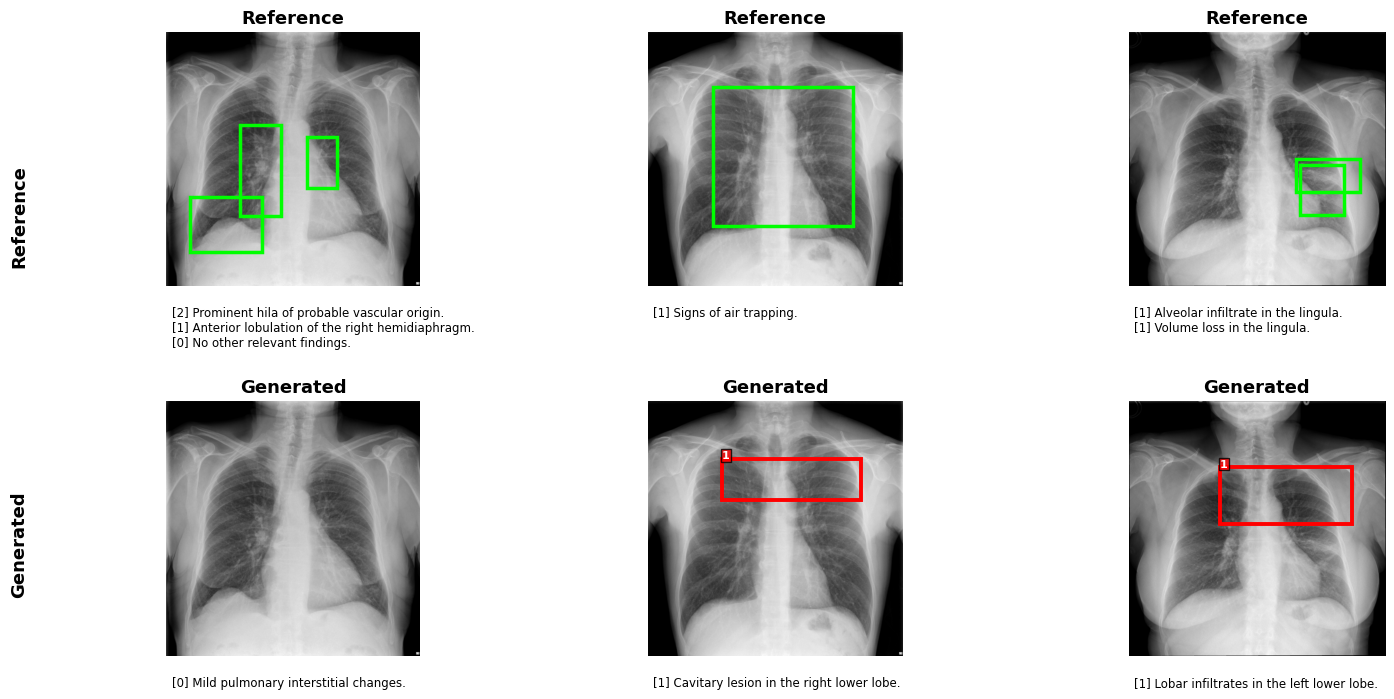

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ============================================================
# QUALITATIVE FIGURE — 3 EXAMPLES SIDE BY SIDE
# Reference | Generated
# ============================================================

show = te_abn[:4]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

# Colour palette for generated boxes
box_colors = [
    "red",
    "cyan",
    "yellow",
    "lime"
]

for c, s in enumerate(show):

    # --------------------------------------------------------
    # Generate report + predicted boxes
    # --------------------------------------------------------

    generated = parse_generation(
        generate_constrained(
            s,
            max_new=200,
            max_obj=4
        )
    )

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    img = Image.open(s["path"]).convert("L")
    W, H = img.size

    # ========================================================
    # REFERENCE
    # ========================================================

    ax = axes[0, c]

    ax.imshow(img, cmap="gray")

    reference_text = []

    for sent, boxes in zip(
        s["sentences"],
        s["boxes"]
    ):

        reference_text.append(
            f"[{len(boxes)}] {sent}"
        )

        # Reference boxes
        for box in boxes:

            x1, y1, x2, y2 = box

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor="lime",
                linewidth=2.5
            )

            ax.add_patch(rect)

    ax.set_title(
        "Reference",
        fontsize=13,
        fontweight="bold"
    )

    # Report below image
    ax.text(
        0.02,
        -0.08,
        "\n".join(reference_text),
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        ha="left",
        wrap=True
    )

    ax.axis("off")

    # ========================================================
    # GENERATED
    # ========================================================

    ax = axes[1, c]

    ax.imshow(img, cmap="gray")

    generated_text = []

    box_count = 0

    for sent, boxes in generated:

        generated_text.append(
            f"[{len(boxes)}] {sent}"
        )

        for box in boxes:

            # Convert predicted box to normalized coordinates
            x1, y1, x2, y2 = normalise_box(box)

            # Convert normalized -> image coordinates
            x1 *= W
            x2 *= W
            y1 *= H
            y2 *= H

            # Cycle through colours
            color = box_colors[
                box_count % len(box_colors)
            ]

            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor=color,
                linewidth=2.8
            )

            ax.add_patch(rect)

            # Optional box number
            ax.text(
                x1,
                y1,
                str(box_count + 1),
                fontsize=8,
                fontweight="bold",
                color="white",
                bbox=dict(
                    facecolor=color,
                    alpha=0.8,
                    pad=1
                )
            )

            box_count += 1

    ax.set_title(
        "Generated",
        fontsize=13,
        fontweight="bold"
    )

    ax.text(
        0.02,
        -0.08,
        "\n".join(generated_text),
        transform=ax.transAxes,
        fontsize=8.5,
        va="top",
        ha="left",
        wrap=True
    )

    ax.axis("off")


# ============================================================
# Row labels
# ============================================================

fig.text(
    0.01,
    0.70,
    "Reference",
    rotation=90,
    fontsize=13,
    fontweight="bold",
    va="center"
)

fig.text(
    0.01,
    0.29,
    "Generated",
    rotation=90,
    fontsize=13,
    fontweight="bold",
    va="center"
)


# ============================================================
# Layout
# ============================================================

plt.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.93,
    bottom=0.15,
    wspace=0.08,
    hspace=0.45
)

plt.savefig(
    f"{OUT_ROOT}/{RUN}/qualitative_3examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
for s in te_abn[:6]:
    print("=" * 74)
    print("REFERENCE")
    for t, b in zip(s["sentences"], s["boxes"]):
        print(f"  [{len(b)} box] {t[:62]}")
    print("GENERATED")
    for t, b in parse_generation(generate_constrained(s, max_new=200)):
        bs = "  ".join("(" + ",".join(f"{v:.2f}" for v in normalise_box(x)) + ")"
                       for x in b)
        print(f"  [{len(b)} box] {t[:62]}")
        if b: print(f"           {bs}")

REFERENCE
  [2 box] Prominent hila of probable vascular origin.
  [1 box] Anterior lobulation of the right hemidiaphragm.
  [0 box] No other relevant findings.
GENERATED
  [1 box] Aortic elongation.
           (0.52,0.42,0.65,0.77)
REFERENCE
  [1 box] Signs of air trapping.
GENERATED
  [0 box] No significant findings.
REFERENCE
  [1 box] Alveolar infiltrate in the lingula.
  [1 box] Volume loss in the lingula.
GENERATED
  [2 box] Increased calcifications in the right hilar region.
           (0.00,0.55,0.42,0.65)  (0.42,0.52,0.55,0.65)
REFERENCE
  [1 box] Dorsolumbar scoliosis.
GENERATED
  [1 box] Chronic changes of bronchial obstruction.
           (0.16,0.29,0.90,0.68)
REFERENCE
  [1 box] Abscess.
  [1 box] Cavitary mass in the left upper lobe.
  [1 box] Nodule projected in the lower right field.
  [1 box] Probable nipple.
GENERATED
  [1 box] Infiltrates in the left lung parenchyma.
           (0.32,0.39,0.84,0.68)
REFERENCE
  [1 box] Small laminar atelectasis in the left costophreni